## 1. Importar librerías

In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

## 2. Cargar datos y modelos

In [145]:
test = pd.read_csv("../data/processed/test.csv")

X_test = test.drop(columns=["fecha_hora", "helada_24h"])
y_test = test["helada_24h"]

rf = joblib.load("../models/random_forest.pkl")
svm = joblib.load("../models/svm.pkl")
mlp = joblib.load("../models/neural_network.pkl")
ensemble = joblib.load("../models/ensemble.pkl")

## 3. Obtener predicciones

In [146]:
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)
mlp_pred = mlp.predict(X_test)

rf_proba = rf.predict_proba(X_test)[:,1]
svm_proba = svm.predict_proba(X_test)[:,1]
mlp_proba = mlp.predict_proba(X_test)[:,1]

## 4. Métricas comparativas

In [147]:
def get_metrics(name, y_true, y_pred):
    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

results = pd.DataFrame([
    get_metrics("Random Forest", y_test, rf_pred),
    get_metrics("SVM", y_test, svm_pred),
    get_metrics("MLP", y_test, mlp_pred)
])

results

,Modelo,Accuracy,Precision,Recall,F1
0,Random Forest,0.793559,0.434160,0.966030,0.599078
1,SVM,0.821356,0.433962,0.390658,0.411173
2,MLP,0.826441,0.443213,0.339703,0.384615


## 5. Gráficas comparativas

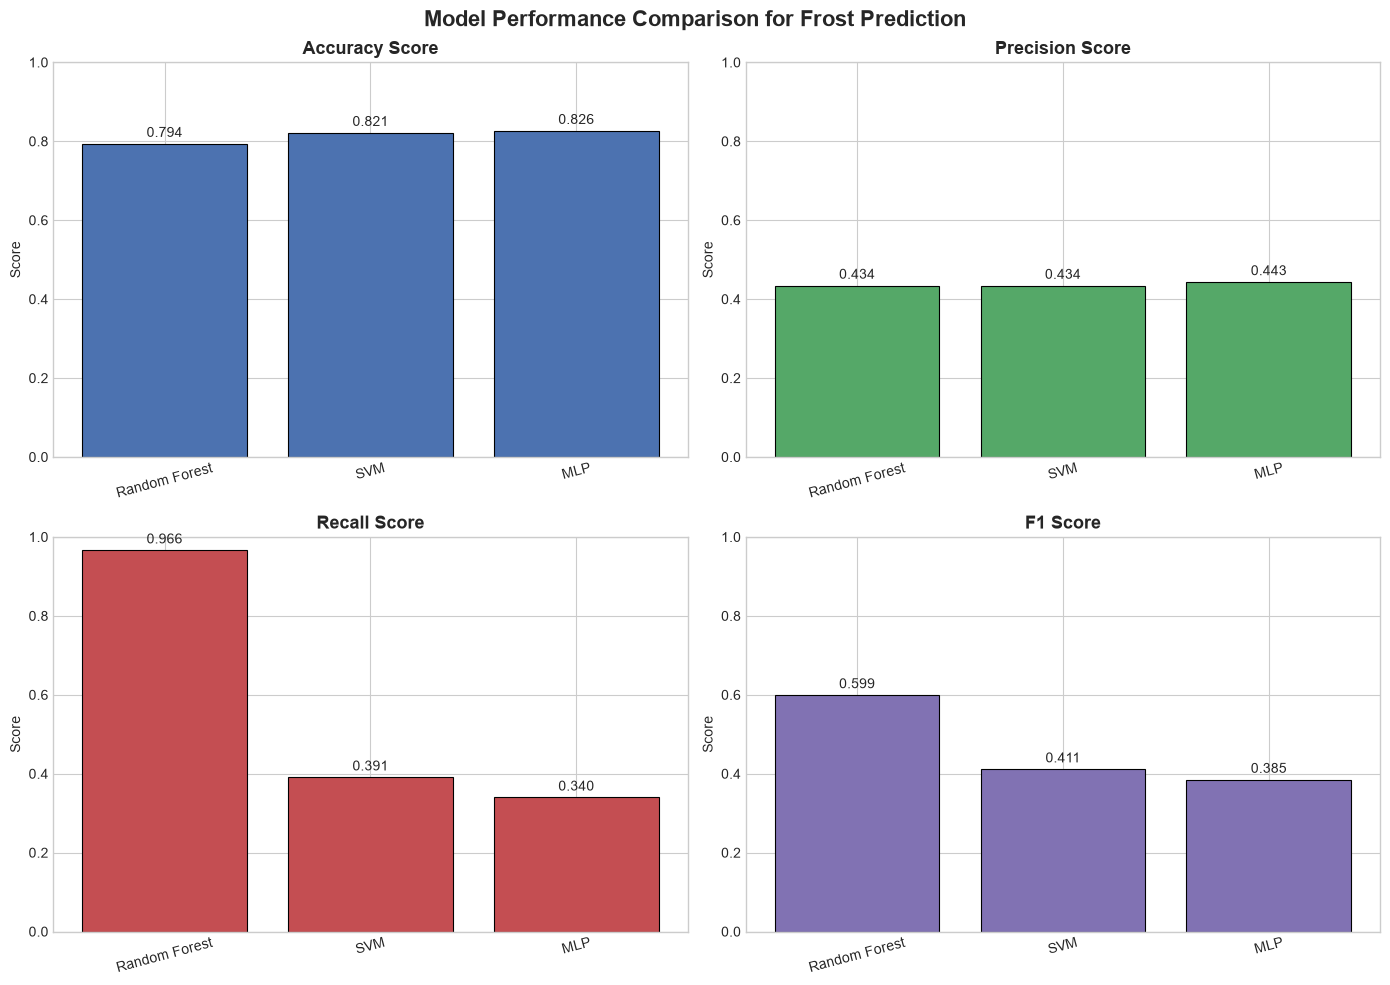

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar modelos (opcional pero recomendado para paper)
df_plot = results.copy()

models = df_plot["Modelo"]
metrics = ["Accuracy", "Precision", "Recall", "F1"]

plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        models,
        df_plot[metric],
        color=colors[i],
        edgecolor="black",
        linewidth=0.8
    )

    axes[i].set_title(f"{metric} Score", fontsize=13, fontweight="bold")
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Score")

    # valores encima de las barras
    for bar in bars:
        height = bar.get_height()
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle(
    "Model Performance Comparison for Frost Prediction",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 6. Matrices de confusión

### Random Forest

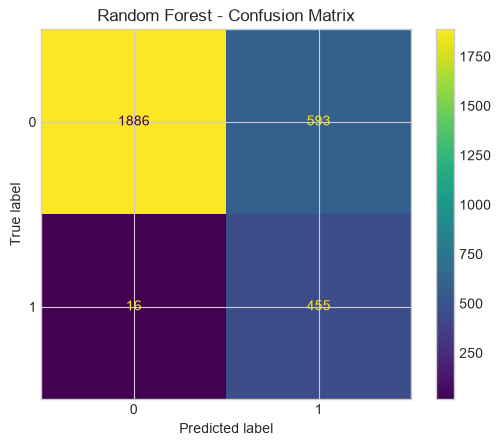

In [149]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

### Support Vector Machine

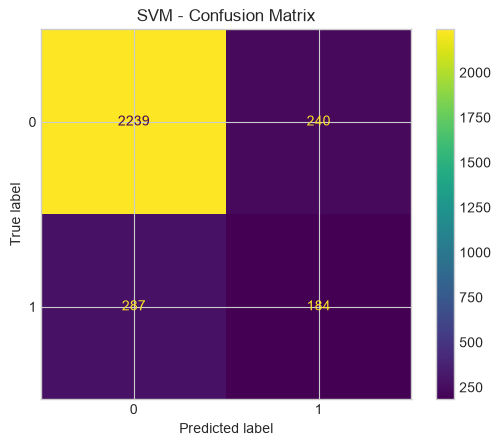

In [150]:
cm = confusion_matrix(y_test, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("SVM - Confusion Matrix")
plt.show()

### MLP

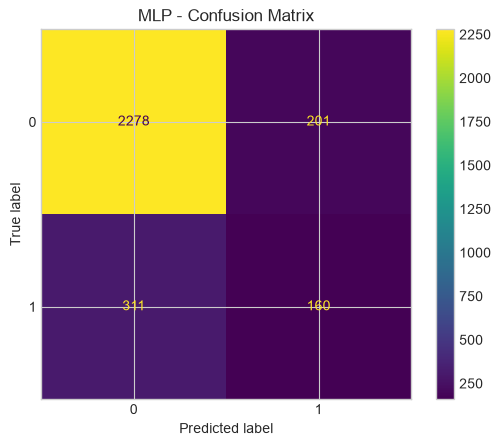

In [151]:
cm = confusion_matrix(y_test, mlp_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("MLP - Confusion Matrix")
plt.show()

## 7. Curva ROC

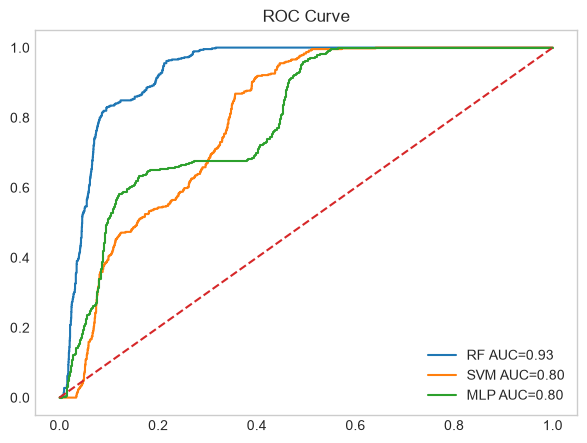

In [152]:
plt.figure(figsize=(7,5))

for name, proba in [
    ("RF", rf_proba),
    ("SVM", svm_proba),
    ("MLP", mlp_proba)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

## 8. Análisis de threshold

Best threshold (by F1): 0.37


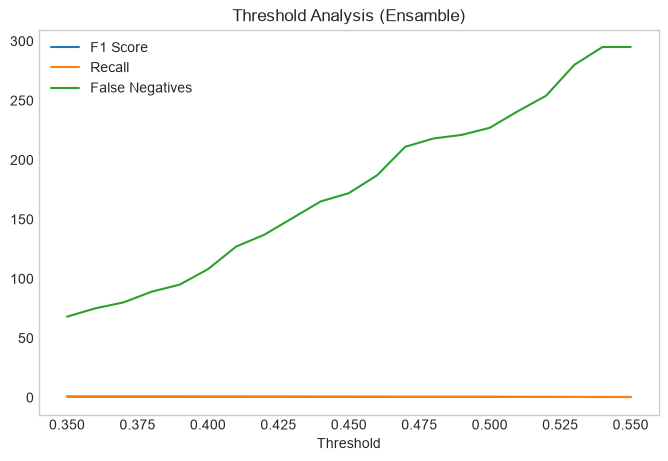

In [153]:
thresholds = np.arange(0.35, 0.55, 0.01)

f1_scores = []
recall_scores = []
fn_scores = []

ensemble_proba = (
    0.50 * rf_proba +
    0.25 * svm_proba +
    0.25 * mlp_proba
)

for t in thresholds:
    pred = (ensemble_proba >= t).astype(int)

    f1_scores.append(f1_score(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    recall_scores.append(tp / (tp + fn))
    fn_scores.append(fn)

best_threshold = thresholds[np.argmax(f1_scores)]

print("Best threshold (by F1):", best_threshold)

plt.figure(figsize=(8,5))

plt.plot(thresholds, f1_scores, label="F1 Score")
plt.plot(thresholds, recall_scores, label="Recall")
plt.plot(thresholds, fn_scores, label="False Negatives")

plt.title("Threshold Analysis (Ensamble)")
plt.xlabel("Threshold")
plt.legend()
plt.grid()
plt.show()

## 9. Análisis de falsos negativos

In [154]:
ensemble_pred = (ensemble_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, ensemble_pred)

tn, fp, fn, tp = cm.ravel()

print("Falsos negativos (HELADAS NO DETECTADAS):", fn)
print("Falsos positivos (ALARMAS FALSAS):", fp)
print("Verdaderos positivos (HELADAS DETECTADAS):", tp)
print("Verdaderos negativos (NO HAY HELADAS):", tn)

Falsos negativos (HELADAS NO DETECTADAS): 80
Falsos positivos (ALARMAS FALSAS): 306
Verdaderos positivos (HELADAS DETECTADAS): 391
Verdaderos negativos (NO HAY HELADAS): 2173
